In [ ]:
# Import required Librareis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Load the Dataset
def load_data(path):
    df = pd.read_csv(path)
    print("Dataset Loaded Successfully!")
    print(df.head())
    return df


data = load_data("Iris.csv")

Dataset Loaded Successfully!
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
# Data Preprocessing
def preprocess(df):
    # Drop unnecessary column if exists
    if 'Id' in df.columns:
        df = df.drop('Id', axis=1)

    # Encode target column
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    return df, le


data, encoder = preprocess(data)

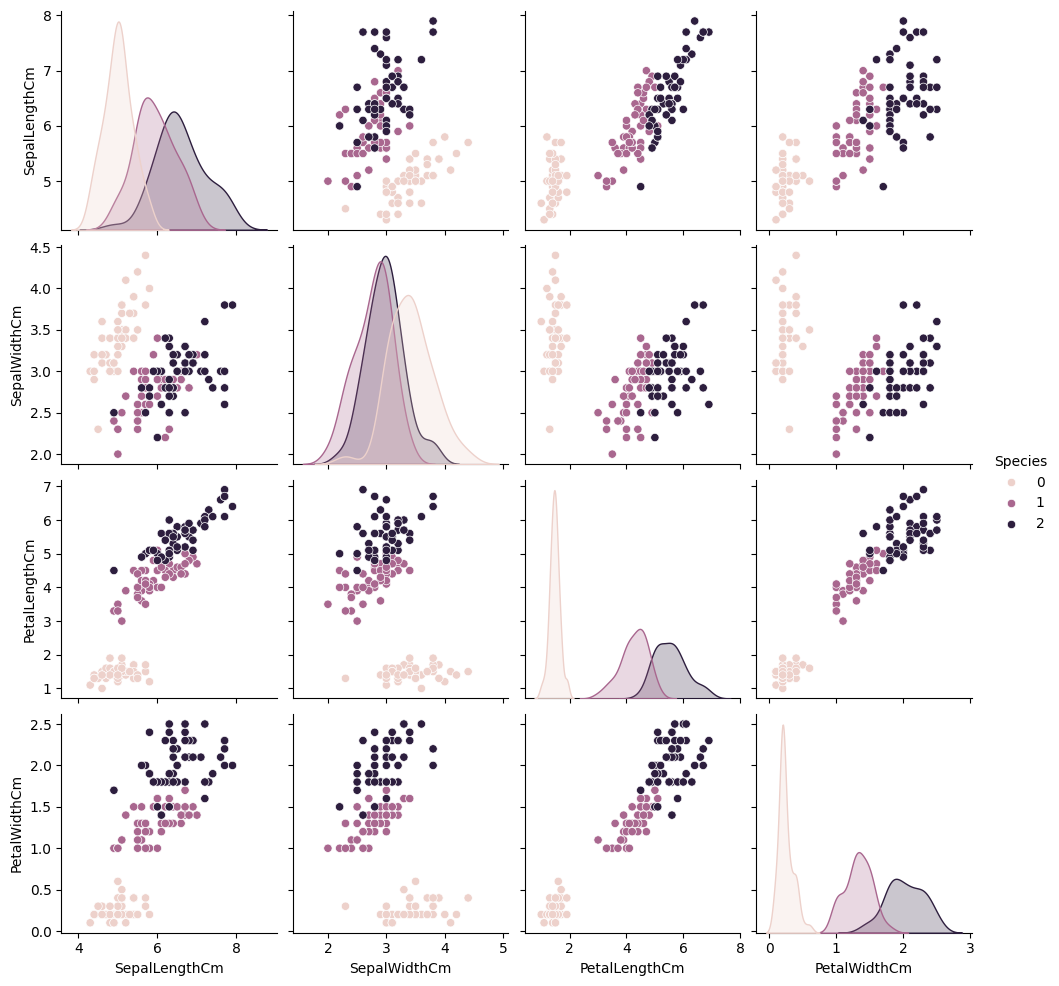

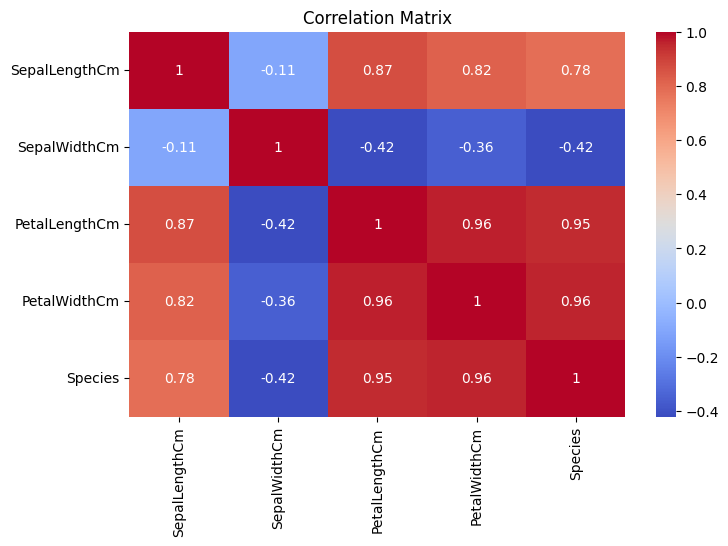

In [ ]:
# EDA
def visualize(df):
    sns.pairplot(df, hue='Species')
    plt.show()

    plt.figure(figsize=(8,5))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()


visualize(data)

In [ ]:
# Feature & Target Split
X = data.drop('Species', axis=1)
y = data['Species']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train Multiple Models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [ ]:
# Evaluate Models
def evaluate(models, X_train, X_test, y_train, y_test):
    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        results[name] = acc

        print(f"\n{name} Results:")
        print("Accuracy:", acc)
        print(classification_report(y_test, preds))

    return results


results = evaluate(models, X_train, X_test, y_train, y_test)


Decision Tree Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


SVM Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


KNN Results:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00  

In [ ]:
# Best Model Selection
best_model = max(results, key=results.get)
print("\nBest Model is:", best_model)


Best Model is: Decision Tree


Histogram , Trend , column , and Pie Chart

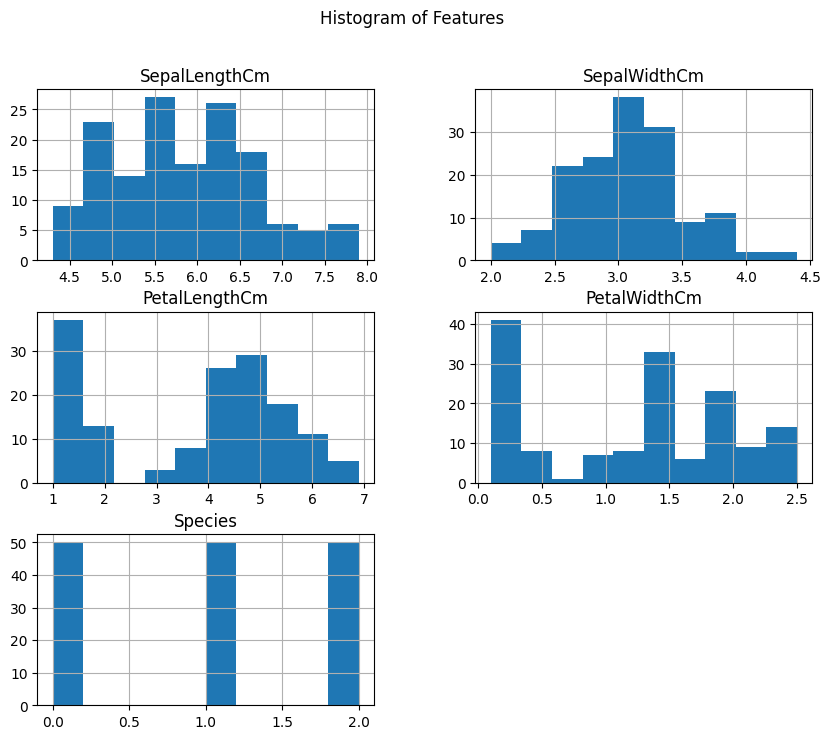

In [ ]:
# Histogram
df.hist(figsize=(10,8))
plt.suptitle("Histogram of Features")
plt.show()

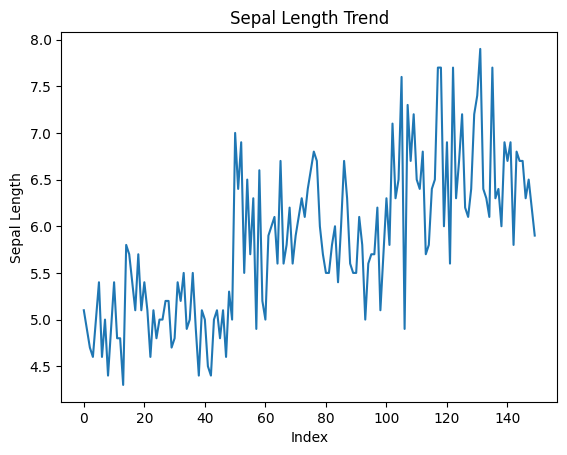

In [ ]:
#line chart or Trend chart
plt.figure()
plt.plot(df.index, df['SepalLengthCm'])
plt.title("Sepal Length Trend")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()

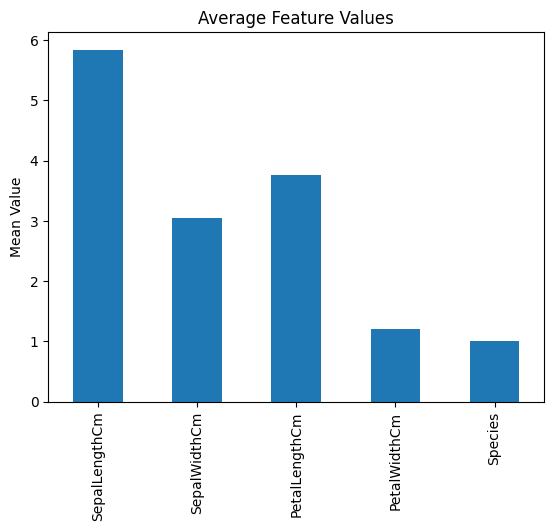

In [ ]:
# column chart
df.mean().plot(kind='bar')
plt.title("Average Feature Values")
plt.ylabel("Mean Value")
plt.show()

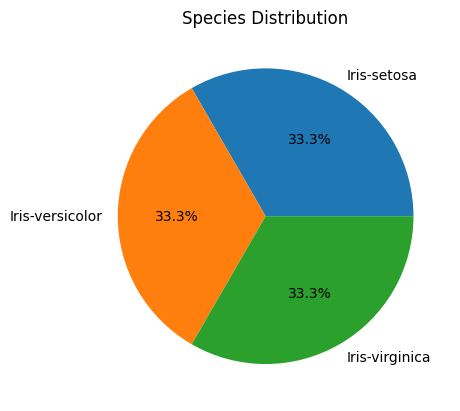

In [ ]:
# Pie chart
species_counts = df['Species'].value_counts()
plt.figure()
plt.pie(species_counts, labels=le.classes_, autopct='%1.1f%%')
plt.title("Species Distribution")
plt.show()